In [1]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests

pd.set_option('display.max_columns', None)

from config import *
from inventory_processing_functions import *

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Identify which site to process (`Sequoia` or `TharpsCreek`)

In [2]:
site = 'Sequoia' # Sequoia or TharpsCreek

# Import tree-level data from data archive

In [3]:
# Citation: Das, A.J., 2026, Sequoia National Park tree growth data for thinning and burning study: 
# U.S. Geological Survey data release, https://doi.org/10.5066/P1MHZKJY.


# 1. Define the unique item ID from ScienceBase link
item_id = "699dd98ab66b018a7ec1079a"
metadata_url = f"https://www.sciencebase.gov/catalog/item/{item_id}?format=json"

# 2. Get the metadata JSON
response = requests.get(metadata_url).json()

# 3. Create a dictionary to hold DataFrames
dataframes = {}

# 4. Loop through the files attached to the repository item
if "files" in response:
    for file_info in response["files"]:
        # Filter for CSV files
        if file_info["name"].endswith(".csv"):
            file_name = file_info["name"]
            file_url = file_info["url"]

            print(f"Reading '{file_name}' directly into memory...")

            # pd.read_csv accepts web URLs natively and streams them straight to memory
            dataframes[file_name] = pd.read_csv(file_url)
else:
    print("No files found associated with this item ID.")

# 5. Access dataframes by their filenames
all_trees = dataframes['SequoiaTharpsThinBurnStudy_TreeData.csv']
all_plots = dataframes['SequoiaTharpsThinBurnStudy_PlotData.csv']

Reading 'SequoiaTharpsThinBurnStudy_PlotData.csv' directly into memory...
Reading 'SequoiaTharpsThinBurnStudy_TreeData.csv' directly into memory...


# Preliminary data cleaning and filtering

In [4]:
# Select plots associated with site
if site == 'Sequoia':
    tree_raw = all_trees.loc[all_trees['PLOT'].str.contains('FFS')].copy()
    plot_raw = all_plots.loc[all_plots['Plot'].str.contains('FFS')].copy()
elif site == 'TharpsCreek':
    tree_raw = all_trees.loc[all_trees['PLOT'].isin(['LOLOG', 'UPLOG', 'LOTHAR', 'UPTHAR'])].copy()
    plot_raw = all_plots.loc[all_plots['Plot'].isin(['LOLOG', 'UPLOG', 'LOTHAR', 'UPTHAR'])].copy()
else:
    print('Site does not exist in data.')

In [5]:
# Add a unique tree identifier column

# Unique ID = Plot + Tag
tree_raw['TreeID'] = tree_raw['PLOT'] + '_' + tree_raw['TAGNUMBER'].astype(str)

In [6]:
# Specify columns that contain years or DBH measurements
year_cols = [i for i in tree_raw.columns if 'YEAR' in i] + ['YearFirstRecorded'] + ['MortalityYear']
dbh_cols = [i for i in tree_raw.columns if 'DBH' in i]
dbh_cols, year_cols

(['DBH0',
  'DBH1',
  'DBH2',
  'DBH3',
  'DBH4',
  'DBH5',
  'DBH6',
  'DBH7',
  'DBH8',
  'DBH9',
  'DBHMort'],
 ['YEAR1',
  'YEAR2',
  'YEAR3',
  'YEAR4',
  'YEAR5',
  'YEAR6',
  'YEAR7',
  'YEAR8',
  'YEAR9',
  'YearFirstRecorded',
  'MortalityYear'])

In [7]:
# Check that category types are clean for important columns (look for null or strange values)
for cat in ['PLOT','SppCode', 'IngrowthYear'] + year_cols:
    print(cat)
    print(*tree_raw[cat].unique())
    print(tree_raw[cat].dtype)
print("Total number of plots")
print(len(tree_raw['PLOT'].unique()))
print("Total number of trees")
print(len(tree_raw['TreeID'].unique()))

PLOT
FFS5BURN FFS2BURN FFS6BURN FFS7CONTROL
object
SppCode
PILA CADE ABCO ABMA PIPO QUKE PIJE SEGI
object
IngrowthYear
-99 2022 2004 2021 2023 2008 2019 2020 2007 2015 2017 2018 2016 2010 2011 2014 2006 2013 2012 2003 2005 2009
int64
YEAR1
2001.0 nan
float64
YEAR2
nan 2006.0
float64
YEAR3
nan 2011.0 2012.0
float64
YEAR4
nan 2016.0
float64
YEAR5
nan 2021.0 2013.0
float64
YEAR6
nan
float64
YEAR7
nan
float64
YEAR8
nan
float64
YEAR9
nan
float64
YearFirstRecorded
2001 2022 2004 2021 2023 2008 2019 2020 2007 2015 2017 2018 2016 2010 2011 2014 2006 2013 2005 2012 2009 2003
int64
MortalityYear
2002 2023 2005 2003 -99 2020 2007 2004 2012 2022 2006 2019 2014 2013 2015 2021 2016 2009 2008 2017 2018 2011 2010
int64
Total number of plots
4
Total number of trees
3273


## General data check

Some notes from the data provider (Adrian Das, 4/10/24):

* IngrowthYear-- if the tree was ingrowth (i.e., grew to 1.37m after plot establishment), this is the year it became ingrowth. Recall that ingrowth were only measured annually after 1998. Prior to that they were only added during diameter remeasurement years. -99 indicates we don't know the year the tree reached breast height (which is true for any non ingrowth trees)
* YearFirstRecorded-- first year the tree was tracked. Usually this is the plot establishment or the ingrowth year, but rarely a tree might have been 'missed' and added to the database in a different year
* MortalityYear-- year the tree was found dead. -99 if the tree is still alive
* DBH0-- dbh at ingrowth year. Blank if not an ingrowth
* DBH1 to DBH8: DBH at each measurement year
* Year1 to Year8: Year the given dbh measurement was taken
* DBHMort: Dbh at the year of mortality for trees that died.

For Tharp's Creek, there are a couple of trees for which both IngrowthYear and YearFirstRecorded are -99. I don't take any action on these because the rest of the timeseries are intact. 

In [8]:
# Where does YearFirstRecorded = -99?
tree_raw.loc[tree_raw['YearFirstRecorded']==-99]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID


For Tharp's Creek, there is one ingrowth tree for which the IngrowthYear and the YearFirstRecorded are not equal. So in almost all cases, it won't matter which of these I use as Year0. I will use "YearFirstRecorded" (and not use IngrowthYear).

In [9]:
# Does YearFirstRecorded == IngrowthYear for all ingrowth?
notIngrowth = tree_raw.loc[tree_raw['IngrowthYear']!=-99]
notIngrowth.loc[notIngrowth['IngrowthYear']!=notIngrowth['YearFirstRecorded']]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID


I checked that all trees that have a valid DBHMort also have a nonnull MortalityYear. For Sequoia, there is one tree with a non-null DBHMort that does not have an associated mortality year. However, mortality appears to take place after 2021, so this record will eventually be automatically removed from the analysis.

In [10]:
# All trees with DBHMort should have a nonnull Mortality year
print(tree_raw.loc[(tree_raw['DBHMort'].isnull()==False) & (tree_raw['MortalityYear']==-99), 'DBHMort'].unique())
tree_raw.loc[(tree_raw['DBHMort']!=-99) & (tree_raw['MortalityYear']==-99), 'DBHMort'].unique()
tree_raw.loc[(tree_raw['DBHMort'].isnull()==False) & (tree_raw['MortalityYear']==-99)]
tree_raw.loc[(tree_raw['DBHMort']!=-99) & (tree_raw['MortalityYear']==-99) & (tree_raw['DBHMort'].isnull()==False)]

[28.5]


,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
2696,FFS7CONTROL,12,4988,CADE,-99,2001,-99,NaN,27.6,28.5,29.1,30.1,30.8,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,28.5,FFS7CONTROL_4988


Several trees have YearFirstRecorded after the DBH1 year. I don't do anything special with these; they will be resolved when I remove the pre-treatment data and/or clean the null entries.

In [11]:
# Identify instances where YearFirstRecorded is later than the DBH1 year
frst_yr_msmtch = tree_raw.loc[tree_raw['YearFirstRecorded']>tree_raw['YEAR1']]
frst_yr_msmtch

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
602,FFS2BURN,6,8416,ABCO,-99,2005,2006,NaN,-99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.4,FFS2BURN_8416
603,FFS2BURN,6,8417,ABCO,-99,2006,2020,NaN,-99.0,20.8,21.7,22.5,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,23.1,FFS2BURN_8417
1867,FFS6BURN,11,1354,ABCO,-99,2006,-99,NaN,-99.0,43.6,46.9,53.4,56.7,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,NaN,FFS6BURN_1354
1877,FFS6BURN,15,1365,ABCO,-99,2009,-99,NaN,-99.0,-99.0,69.7,72.4,74.2,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,NaN,FFS6BURN_1365
1878,FFS6BURN,15,1366,ABCO,-99,2009,-99,NaN,-99.0,-99.0,58.2,60.1,61.0,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,NaN,FFS6BURN_1366
2980,FFS7CONTROL,4,5702,ABCO,2003,2003,2022,0.0,11.1,12.2,12.8,13.8,14.7,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,14.8,FFS7CONTROL_5702
2981,FFS7CONTROL,2,5703,PILA,2003,2003,2014,0.3,14.3,15.2,15.6,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,16.1,FFS7CONTROL_5703
3217,FFS7CONTROL,2,6293,ABCO,2003,2003,2022,1.0,1.0,1.0,1.0,1.1,1.2,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,1.2,FFS7CONTROL_6293
3218,FFS7CONTROL,11,6294,ABCO,2003,2003,2022,0.1,0.1,-99.0,1.4,1.7,2.2,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2.1,FFS7CONTROL_6294
3219,FFS7CONTROL,12,6295,PILA,2003,2003,2007,2.6,2.6,2.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8,FFS7CONTROL_6295


In [12]:
# Check for "pure" duplicates (hopefully this is empty)

dupes = tree_raw.loc[tree_raw.duplicated()]
assert(len(dupes)==0)

In [13]:
# Check for trees that have more than one record (i.e., "non-pure duplicates")
# Hopefully, this is empty

nonpureDupes = tree_raw.loc[tree_raw[['TreeID']].duplicated()]
assert(len(nonpureDupes)==0)

In [14]:
# Check for null values in TreeID columns
assert(len(tree_raw.loc[tree_raw['TreeID'].isnull()])==0)

According to multiple studies based on this dataset (e.g., Das et al. 2016, Das 2012, Stephenson et al. 2019, Das and Stephenson 2015, Das et al. 2013, Van Mantgem and Stephenson 2007, Aubry-Kientz and Moran 2017), the threshold for measurement is any tree >=1.37m tall. Height is not reported in the dataset; I therefore assume all trees in the dataset met the threshold (I confirmed this assumption with the data providers).

In [15]:
# check for unexpected values in DBH column (nulls, 999, 0...)
tree_raw.describe(include='all')
# There are lots of DBH = -99, which I'll remove in the next section

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
count,3273,3273.000000,3273.000000,3273,3273.000000,3273.000000,3273.000000,1079.000000,1965.000000,1044.000000,999.000000,1101.000000,1656.000000,0.0,0.0,0.0,0.0,1965.0,1044.0,999.000000,1101.0,1656.000000,0.0,0.0,0.0,0.0,1666.000000,3273
unique,4,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3273
top,FFS5BURN,NaN,NaN,ABCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFS7CONTROL_9526
freq,1107,NaN,NaN,1860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,7.080965,5033.328139,NaN,751.250229,2008.186984,1379.950810,-31.031761,27.554702,33.694923,36.372272,32.517702,19.804167,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.007007,2016.0,2020.985507,NaN,NaN,NaN,NaN,-2.557017,NaN
std,NaN,4.716133,1634.534609,NaN,1038.326218,9.077861,967.745196,46.623009,33.563815,41.557070,38.074991,36.690364,31.862641,NaN,NaN,NaN,NaN,0.0,0.0,0.083456,0.0,0.340297,NaN,NaN,NaN,NaN,56.764095,NaN
min,NaN,1.000000,879.000000,NaN,-99.000000,2001.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,0.300000,0.300000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2013.000000,NaN,NaN,NaN,NaN,-99.000000,NaN
25%,NaN,3.000000,4089.000000,NaN,-99.000000,2001.000000,-99.000000,-99.000000,6.200000,7.200000,7.950000,4.800000,1.300000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2021.000000,NaN,NaN,NaN,NaN,0.800000,NaN
50%,NaN,6.000000,4930.000000,NaN,-99.000000,2001.000000,2003.000000,0.500000,15.400000,22.500000,23.600000,17.500000,3.800000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2021.000000,NaN,NaN,NaN,NaN,6.900000,NaN
75%,NaN,11.000000,5762.000000,NaN,2019.000000,2019.000000,2022.000000,0.900000,35.000000,53.400000,56.700000,47.700000,24.600000,NaN,NaN,NaN,NaN,2001.0,2006.0,2011.000000,2016.0,2021.000000,NaN,NaN,NaN,NaN,22.875000,NaN


## Transform dataframe from wide to long

In [16]:
# Map DBH columns to year colums
dbh_yr_dct = dict(zip(['DBH'+str(i) for i in np.arange(1,10)], ['YEAR' + str(i) for i in np.arange(1,10)]))
dbh_yr_dct['DBH0'] = 'YearFirstRecorded'
dbh_yr_dct['DBHMort'] = 'MortalityYear'
dbh_yr_dct

{'DBH1': 'YEAR1',
 'DBH2': 'YEAR2',
 'DBH3': 'YEAR3',
 'DBH4': 'YEAR4',
 'DBH5': 'YEAR5',
 'DBH6': 'YEAR6',
 'DBH7': 'YEAR7',
 'DBH8': 'YEAR8',
 'DBH9': 'YEAR9',
 'DBH0': 'YearFirstRecorded',
 'DBHMort': 'MortalityYear'}

In [17]:
# Melt dataframe (wide to long)
dbh_long = melt_inventory_df(tree_raw,
                             vars_to_melt = dbh_cols,
                                id_vars=['PLOT','TreeID','SppCode'] + year_cols,
                                var_name='DBH_timeframe')
dbh_long.rename(columns={'value':'DBH'},inplace=True)
dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH
0,FFS5BURN,FFS5BURN_4038,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
1,FFS5BURN,FFS5BURN_4039,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
2,FFS5BURN,FFS5BURN_4040,CADE,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
3,FFS5BURN,FFS5BURN_4041,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
4,FFS5BURN,FFS5BURN_4042,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35998,FFS7CONTROL,FFS7CONTROL_9521,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.9
35999,FFS7CONTROL,FFS7CONTROL_9522,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.7
36000,FFS7CONTROL,FFS7CONTROL_9524,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.5
36001,FFS7CONTROL,FFS7CONTROL_9525,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,1.4


In [18]:
# Convert Year columns to a measurement year for each record
dbh_long['Year'] = np.nan

for key in dbh_yr_dct:
  dbh_long.loc[dbh_long['DBH_timeframe']==key, 'Year'] = dbh_long.loc[dbh_long['DBH_timeframe']==key, dbh_yr_dct[key]]
dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year
0,FFS5BURN,FFS5BURN_4038,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
1,FFS5BURN,FFS5BURN_4039,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
2,FFS5BURN,FFS5BURN_4040,CADE,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
3,FFS5BURN,FFS5BURN_4041,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
4,FFS5BURN,FFS5BURN_4042,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH0,NaN,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35998,FFS7CONTROL,FFS7CONTROL_9521,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.9,2022.0
35999,FFS7CONTROL,FFS7CONTROL_9522,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.7,2022.0
36000,FFS7CONTROL,FFS7CONTROL_9524,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.5,2022.0
36001,FFS7CONTROL,FFS7CONTROL_9525,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,1.4,2022.0


In [19]:
# Add a status column
dbh_long['Status'] = 'Live'
dbh_long.loc[dbh_long['DBH_timeframe']=='DBHMort', 'Status'] = 'Dead'

In [20]:
# Set column variables

treeid_col = 'TreeID' # Tree ID
date_col = 'Year' # Inventory date
dbh_col = 'DBH' # DBH
species_col = 'SppCode' # Species
status_col = 'Status' # Life status
dead_ind = 'Dead' # Status value if tree is dead
live_ind = "Live" # Status value if tree is alive
date_incr = 'year' # Inventory date increment (day or year)
unit_col = 'PLOT' # Treatment unit ID
year_col = 'Year' # Inventory Year

## Check for duplicated, null, and fill values

In [21]:
# Remove null measurements/years
dbh_long.drop(dbh_long.loc[dbh_long['DBH'].isnull()].index, inplace=True)
dbh_long.drop(dbh_long.loc[dbh_long['DBH']==-99].index, inplace=True)

assert len(dbh_long.loc[dbh_long['DBH'].isnull()])==0
assert len(dbh_long.loc[dbh_long['DBH']==-99])==0

dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
33,FFS2BURN,FFS2BURN_1495,ABCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.6,2022.0,Live
91,FFS5BURN,FFS5BURN_3429,CADE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.6,2022.0,Live
92,FFS5BURN,FFS5BURN_3430,CADE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,1.7,2022.0,Live
93,FFS5BURN,FFS5BURN_3431,ABCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.6,2022.0,Live
94,FFS5BURN,FFS5BURN_3432,CADE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,-99,DBH0,0.4,2022.0,Live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,FFS7CONTROL,FFS7CONTROL_8542,CADE,NaN,NaN,NaN,2016.0,2021.0,NaN,NaN,NaN,NaN,2016,2022,DBHMort,1.5,2022.0,Dead
35998,FFS7CONTROL,FFS7CONTROL_9521,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.9,2022.0,Dead
35999,FFS7CONTROL,FFS7CONTROL_9522,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.7,2022.0,Dead
36000,FFS7CONTROL,FFS7CONTROL_9524,CADE,NaN,NaN,NaN,NaN,2021.0,NaN,NaN,NaN,NaN,2020,2022,DBHMort,0.5,2022.0,Dead


In [22]:
# Confirm we don't have any null measurement years
assert len(dbh_long.loc[dbh_long['Year'].isnull()])==0

print(len(dbh_long.loc[dbh_long['Year']==-99]))

# For Sequoia, there is one record with a null year and a non-null DBH
# Drop that record
dbh_long.drop(dbh_long.loc[dbh_long['Year']==-99].index, inplace=True)
dbh_long['Year'].unique()

1


array([2022., 2004., 2023., 2008., 2019., 2007., 2015., 2017., 2018.,
       2010., 2014., 2006., 2013., 2012., 2020., 2003., 2011., 2005.,
       2009., 2001., 2016., 2021., 2002.])

In [23]:
# Check again for duplicates

# Pure
assert(len(dbh_long.loc[dbh_long.duplicated()])==0)

# Non-pure
dbh_long.loc[dbh_long[['TreeID', 'Year']].duplicated()]

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
35454,FFS7CONTROL,FFS7CONTROL_5023,ABCO,2001.0,2006.0,2012.0,NaN,NaN,NaN,NaN,NaN,NaN,2001,2012,DBHMort,44.8,2012.0,Dead


In [24]:
# Remove trees that have duplicate record(s) during the year of mortality
dbh_long.drop(dbh_long.loc[(dbh_long['Year'] == dbh_long['MortalityYear']) & (dbh_long['DBH_timeframe']!='DBHMort')].index, inplace=True)

assert len(dbh_long.loc[dbh_long[['TreeID', 'Year']].duplicated()])==0

In [25]:
# The clean up process drops trees that don't have any DBH measurements associated with them. 
# That's ok.

# Identify trees that were in the master but not the clean dataset
len(dbh_long['TreeID'].unique()), len(tree_raw)
droppedTrees = [i for i in tree_raw['TreeID'].unique() if i not in dbh_long['TreeID'].unique()]
tree_raw.loc[tree_raw['TreeID'].isin(droppedTrees)]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
1701,FFS5BURN,6,5917,CADE,2020,2020,-99,-99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFS5BURN_5917


A few trees have 0cm DBH measurements. After checking, it appears all except one of these were recorded when the tree died. One live tree recorded a DBH of 0 in its first record year. I remove these measurements from the inventory.

In [26]:
# Look at trees with negative or 0cm DBHs
weirdDBH = dbh_long.loc[dbh_long['DBH']<=0]

weirdDBH

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
2980,FFS7CONTROL,FFS7CONTROL_5702,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2003,2022,DBH0,0.0,2003.0,Live
35919,FFS7CONTROL,FFS7CONTROL_5971,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2005,DBHMort,0.0,2005.0,Dead


In [27]:
# Drop 0 or negative DBH measurements
dbh_long.drop(dbh_long.loc[dbh_long['DBH']<=0].index, inplace=True)

In [28]:
# Check again for weird measurements
dbh_long[['PLOT', 'TreeID', 'SppCode', 'DBH_timeframe','DBH','Year']].describe(include='all')

,PLOT,TreeID,SppCode,DBH_timeframe,DBH,Year
count,8773,8773,8773,8773,8773.000000,8773.000000
unique,4,3272,8,7,NaN,NaN
top,FFS7CONTROL,FFS7CONTROL_6293,ABCO,DBH1,NaN,NaN
freq,3536,7,4465,1958,NaN,NaN
mean,NaN,NaN,NaN,NaN,26.103559,2012.045822
std,NaN,NaN,NaN,NaN,33.809942,8.071200
min,NaN,NaN,NaN,NaN,0.050000,2001.000000
25%,NaN,NaN,NaN,NaN,2.600000,2004.000000
50%,NaN,NaN,NaN,NaN,11.100000,2011.000000
75%,NaN,NaN,NaN,NaN,35.200000,2021.000000


In [29]:
# Once a tree dies, it is only recorded once.
# This means that dead tree's last year in the record its first and only dead record.
# Check this assumption:
deads = dbh_long.loc[dbh_long['Status']=='Dead']

assert len(deads) == len(deads['TreeID'].unique())

In [30]:
# How many unique trees, records at this point?
print("No. unique trees:", len(dbh_long[treeid_col].unique()))
print("No. records:", len(dbh_long))

No. unique trees: 3272
No. records: 8773


## Remove trees smaller than 15cm DBH

In [31]:
# For consistency with other sites in the meta-analysis,
# remove trees with diameters smaller than 15 cm

include_small = False

if include_small == False:
  # Include only trees larger than the global minimum measurement threshold across sites
  dbh_long = dbh_long.loc[dbh_long[dbh_col] >=glbl_dbh_min]

dbh_long

,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
3280,FFS5BURN,FFS5BURN_4045,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2023,DBH1,21.2,2001.0,Live
3286,FFS5BURN,FFS5BURN_4054,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2002,DBH1,16.1,2001.0,Live
3287,FFS5BURN,FFS5BURN_4055,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2005,DBH1,85.3,2001.0,Live
3290,FFS5BURN,FFS5BURN_4058,ABCO,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBH1,33.8,2001.0,Live
3294,FFS5BURN,FFS5BURN_4063,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,-99,DBH1,91.9,2001.0,Live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35924,FFS7CONTROL,FFS7CONTROL_5977,PILA,2001.0,2006.0,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,2001,2016,DBHMort,15.4,2016.0,Dead
35926,FFS7CONTROL,FFS7CONTROL_5979,CADE,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2022,DBHMort,36.4,2022.0,Dead
35932,FFS7CONTROL,FFS7CONTROL_5985,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBHMort,18.0,2003.0,Dead
35936,FFS7CONTROL,FFS7CONTROL_5995,CADE,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2023,DBHMort,21.1,2023.0,Dead


## Remove pre-treatment measurements

In [32]:
# Remove pre-treatment measurements
clean_w_pre = dbh_long.copy() # save a pre-treatment version

if site == 'Sequoia':
    clean = dbh_long.loc[dbh_long['Year']>2001].copy()
elif site == 'TharpsCreek':
    clean = dbh_long.loc[dbh_long['Year']>1990].copy()

## Remove measurements after KNP fire

According to the data provider, some of the FFS plots burned in the KNP (wild)fire in 2021. I remove measurements after 2021 (I keep 2021 because KNP happened in September 2021, after the measurements were taken).

In [33]:
if site == 'Sequoia':
    clean = clean.loc[clean['Year']<=2021]

In [34]:
# Reset index
clean.reset_index(inplace=True, drop=True)

# How many unique trees, records at this point?
print("No. unique trees:", len(clean[treeid_col].unique()))
print("No. records:", len(clean))

clean

No. unique trees: 876
No. records: 2681


,PLOT,TreeID,SppCode,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YearFirstRecorded,MortalityYear,DBH_timeframe,DBH,Year,Status
0,FFS5BURN,FFS5BURN_4045,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,2023,DBH2,23.0,2006.0,Live
1,FFS5BURN,FFS5BURN_4063,ABCO,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,-99,DBH2,95.9,2006.0,Live
2,FFS5BURN,FFS5BURN_4069,CADE,2001.0,2006.0,2011.0,2016.0,2021.0,NaN,NaN,NaN,NaN,2001,-99,DBH2,91.7,2006.0,Live
3,FFS2BURN,FFS2BURN_1976,ABCO,2001.0,2006.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2007,DBH2,145.9,2006.0,Live
4,FFS2BURN,FFS2BURN_1981,ABCO,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,2001,2020,DBH2,22.5,2006.0,Live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,FFS7CONTROL,FFS7CONTROL_5892,ABCO,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,2001,2017,DBHMort,23.5,2017.0,Dead
2677,FFS7CONTROL,FFS7CONTROL_5905,ABCO,2001.0,2006.0,2011.0,2016.0,NaN,NaN,NaN,NaN,NaN,2001,2018,DBHMort,26.0,2018.0,Dead
2678,FFS7CONTROL,FFS7CONTROL_5977,PILA,2001.0,2006.0,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,2001,2016,DBHMort,15.4,2016.0,Dead
2679,FFS7CONTROL,FFS7CONTROL_5985,PILA,2001.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,2003,DBHMort,18.0,2003.0,Dead


# Calculate individual tree growth over time

In [35]:
# Drop unnecessary columns

# Keep mortality year
year_cols.remove('MortalityYear')

# Drop the other year cols
clean.drop(columns = year_cols, inplace=True)

# Reset index
clean.reset_index(inplace=True, drop=True)

clean

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live
1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live
2,FFS5BURN,FFS5BURN_4069,CADE,-99,DBH2,91.7,2006.0,Live
3,FFS2BURN,FFS2BURN_1976,ABCO,2007,DBH2,145.9,2006.0,Live
4,FFS2BURN,FFS2BURN_1981,ABCO,2020,DBH2,22.5,2006.0,Live
...,...,...,...,...,...,...,...,...
2676,FFS7CONTROL,FFS7CONTROL_5892,ABCO,2017,DBHMort,23.5,2017.0,Dead
2677,FFS7CONTROL,FFS7CONTROL_5905,ABCO,2018,DBHMort,26.0,2018.0,Dead
2678,FFS7CONTROL,FFS7CONTROL_5977,PILA,2016,DBHMort,15.4,2016.0,Dead
2679,FFS7CONTROL,FFS7CONTROL_5985,PILA,2003,DBHMort,18.0,2003.0,Dead


In [36]:
# Test tree_thru_time function
if site == 'Sequoia':
    t = 'FFS2BURN_1976'
elif site == "TharpsCreek":
    t = 'UPTHAR_5445'
test_tree = tree_thru_time(t, clean, treeid_col, date_col, dbh_col, status_col,
                           dead_ind, date_incr)
test_tree

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
3,FFS2BURN,FFS2BURN_1976,ABCO,2007,DBH2,145.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0
2322,FFS2BURN,FFS2BURN_1976,ABCO,2007,DBHMort,147.5,2007.0,Dead,1.0,1.6,1.6,2006.0,2007.0


In [37]:
# As a visual check, compare the output above to raw data
tree_raw.loc[tree_raw[treeid_col]==t]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID
34,FFS2BURN,5,1976,ABCO,-99,2001,2007,NaN,147.0,145.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001.0,2006.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147.5,FFS2BURN_1976


In [38]:
# Calculate growth records for all trees
# Record trees associated with mismatched species or resurrections

spp_mismatch = []
resurrected = []
ddbh_df_wDead = pd.DataFrame({})


for tree in clean[treeid_col].unique(): # Loop through all trees
  # # Report progress
  # if tree_no % 1000 ==0:
  #   print(tree_no)

  # Get the individual tree's growth timeseries
  single_tree = tree_thru_time(tree, clean, treeid_col, date_col, dbh_col,
                               status_col, dead_ind, date_incr)

  # Append tree-specific data to site-wide list
  ddbh_df_wDead = pd.concat([ddbh_df_wDead, single_tree])

  # tree_no +=1
  # Add the tree to the appropriate list if it is associated with mismatched species or resurrections
  if mismatched_species(tree_df=single_tree,species_col=species_col):
    spp_mismatch.append(tree)
  if resurrected_trees(single_tree,status_col,live_ind=live_ind,dead_ind=dead_ind):
    resurrected.append(tree)
ddbh_df_wDead

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0
632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0
1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0
1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0
1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,FFS7CONTROL,FFS7CONTROL_5704,ABCO,2006,DBHMort,18.0,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0
2659,FFS7CONTROL,FFS7CONTROL_5713,PILA,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0
2662,FFS7CONTROL,FFS7CONTROL_5784,ABCO,2006,DBHMort,88.5,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0
2678,FFS7CONTROL,FFS7CONTROL_5977,PILA,2016,DBHMort,15.4,2016.0,Dead,NaN,NaN,NaN,NaN,2016.0


## Resolve species mismatches

In [39]:
# Were there any trees with inconsistent species records?
print("Number of trees with mismatched species records:")
print(len(spp_mismatch))
print("Tree IDs with mismatched species")
print(spp_mismatch)

Number of trees with mismatched species records:
0
Tree IDs with mismatched species
[]


In [40]:
# Check that each unique tree is only associated with one species
tree_sp = ddbh_df_wDead.groupby([treeid_col,unit_col,species_col],as_index=False, observed = True).count()[[treeid_col,unit_col,species_col]]
assert len(tree_sp) == len(ddbh_df_wDead[treeid_col].unique())

## Resolve tree resurrections

In [41]:
# Were there any trees that were recorded as being resurrected?
print("Number of trees with resurrection records:")
print(len(resurrected))
print("Tree IDs with resurrection records")
print(resurrected)

Number of trees with resurrection records:
0
Tree IDs with resurrection records
[]


For TharpsCreek, there is one resurrected tree. It shows a big jump in DBH after the mortality year. Possible that the tag # was reused? I drop the "Live" year that occurs after the "Dead" year.

In [42]:
# Examine them in raw data
tree_raw.loc[tree_raw['TreeID'].isin(resurrected)]

,PLOT,SUBPLOT,TAGNUMBER,SppCode,IngrowthYear,YearFirstRecorded,MortalityYear,DBH0,DBH1,DBH2,DBH3,DBH4,DBH5,DBH6,DBH7,DBH8,DBH9,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,DBHMort,TreeID


In [43]:
# Drop resurrection records
ddbh_df_wDead.drop(ddbh_df_wDead.loc[(ddbh_df_wDead['TreeID'].isin(resurrected)) & (ddbh_df_wDead['Year'] > ddbh_df_wDead['MortalityYear'])].index,
             inplace=True)
ddbh_df_wDead

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0
632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0
1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0
1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0
1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,FFS7CONTROL,FFS7CONTROL_5704,ABCO,2006,DBHMort,18.0,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0
2659,FFS7CONTROL,FFS7CONTROL_5713,PILA,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0
2662,FFS7CONTROL,FFS7CONTROL_5784,ABCO,2006,DBHMort,88.5,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0
2678,FFS7CONTROL,FFS7CONTROL_5977,PILA,2016,DBHMort,15.4,2016.0,Dead,NaN,NaN,NaN,NaN,2016.0


## Drop remeasurements of dead trees

In [44]:
# Drop second (and further) records for dead trees
# I.e., retain only the first dead tree record
dead_ba_flag = []
for tree in ddbh_df_wDead[treeid_col].unique():
  one_tree = ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col]==tree]
  for i in range(len(one_tree)):
    if i == 0:
      dead_ba_flag.append(0)
    elif (one_tree[status_col].iloc[i]==dead_ind) & (one_tree[status_col].iloc[i-1] == dead_ind):
      dead_ba_flag.append(1)
    else:
      dead_ba_flag.append(0)
ddbh_df_wDead['Remove flag'] = dead_ba_flag

In [45]:
## Some checks
check = ddbh_df_wDead.loc[ddbh_df_wDead['Remove flag']==1]
assert (check[status_col]==dead_ind).all() # All flagged trees are in fact dead
print(check[date_col].unique()) # Can't be the first inventory year
check

[]


,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag


In [46]:
# Drop remeasurements of dead trees
ddbh_df=ddbh_df_wDead.drop(ddbh_df_wDead.loc[ddbh_df_wDead['Remove flag']==1].index)
ddbh_df

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0
632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0
1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0
1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0
1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,FFS7CONTROL,FFS7CONTROL_5704,ABCO,2006,DBHMort,18.0,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0
2659,FFS7CONTROL,FFS7CONTROL_5713,PILA,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0
2662,FFS7CONTROL,FFS7CONTROL_5784,ABCO,2006,DBHMort,88.5,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0
2678,FFS7CONTROL,FFS7CONTROL_5977,PILA,2016,DBHMort,15.4,2016.0,Dead,NaN,NaN,NaN,NaN,2016.0,0


In [47]:
# Check that there are no null DBH measurements
assert len(ddbh_df.loc[ddbh_df[dbh_col].isnull()])==0

# Check that each dead tree is only associated with one death record
assert len(ddbh_df.loc[ddbh_df[status_col]==dead_ind]) == len(ddbh_df.loc[ddbh_df[status_col]==dead_ind, treeid_col].unique())

In [48]:
# How many unique trees, records at this point?
print("No. unique trees:", len(ddbh_df[treeid_col].unique()))
print("No. records:", len(ddbh_df))

No. unique trees: 876
No. records: 2681


## Remove outliers

I calculate growth increment outliers on a species-specific basis.

Outlier definition: mean annual DBH increment is >/< the species-specific mean +/- 3 standard deviations.

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'ABCO'),
  Text(1, 0, 'CADE'),
  Text(2, 0, 'ABMA'),
  Text(3, 0, 'PILA'),
  Text(4, 0, 'PIPO'),
  Text(5, 0, 'QUKE'),
  Text(6, 0, 'PIJE')])

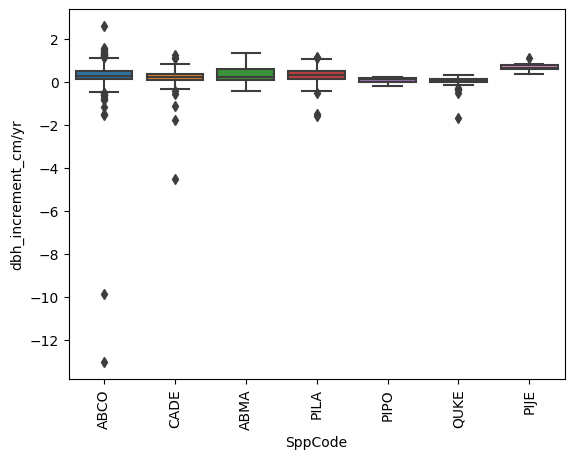

In [49]:
# Quick visualization of outliers
sns.boxplot(ddbh_df, y='dbh_increment_cm/yr', x=species_col)
plt.xticks(rotation = 90)

In [50]:
# Initial pass to identify outliers
outliers = pd.DataFrame()
sp = []
ll = []
ul = []
for s in ddbh_df[species_col].unique(): # Outliers are identified on a species basis
  sp.append(s)
  outs = id_outliers(ddbh_df, s,species_col)
  ll.append(outs[1])
  ul.append(outs[2])
  outliers = pd.concat([outliers, outs[0]])

# Create a lookup table that records the upper and lower growth limits for each species
outlier_dict = pd.DataFrame({'Species':sp,'Lower_limit':ll, 'Upper_limit':ul})
print(outlier_dict)
outliers

  Species  Lower_limit  Upper_limit
0    ABCO    -1.522384     2.163694
1    CADE    -0.904515     1.367425
2    ABMA    -0.657853     1.403993
3    PILA    -0.621475     1.304953
4    PIPO    -0.611954     0.771954
5    QUKE    -0.792620     0.808029
6    PIJE    -0.022495     1.455828


,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag
2421,FFS2BURN,FFS2BURN_5301,ABCO,2007,DBHMort,33.8,2007.0,Dead,1.0,2.6,2.600000,2006.0,2007.0,0
2443,FFS5BURN,FFS5BURN_4074,ABCO,2019,DBHMort,42.5,2019.0,Dead,3.0,-29.6,-9.866667,2016.0,2019.0,0
2544,FFS6BURN,FFS6BURN_1375,ABCO,2013,DBHMort,126.8,2013.0,Dead,2.0,-26.1,-13.050000,2011.0,2013.0,0
2654,FFS7CONTROL,FFS7CONTROL_5577,ABCO,2018,DBHMort,109.5,2018.0,Dead,2.0,-3.1,-1.550000,2016.0,2018.0,0
2448,FFS5BURN,FFS5BURN_4116,CADE,2015,DBHMort,100.0,2015.0,Dead,4.0,-7.0,-1.750000,2011.0,2015.0,0
2512,FFS5BURN,FFS5BURN_4454,CADE,2020,DBHMort,95.4,2020.0,Dead,4.0,-18.0,-4.500000,2016.0,2020.0,0
2513,FFS5BURN,FFS5BURN_4492,CADE,2020,DBHMort,100.5,2020.0,Dead,4.0,-4.4,-1.100000,2016.0,2020.0,0
796,FFS5BURN,FFS5BURN_4114,PILA,-99,DBH3,141.9,2011.0,Live,5.0,-8.0,-1.600000,2006.0,2011.0,0
2637,FFS7CONTROL,FFS7CONTROL_5081,PILA,2017,DBHMort,160.8,2017.0,Dead,1.0,-1.5,-1.500000,2016.0,2017.0,0
953,FFS6BURN,FFS6BURN_5614,QUKE,2022,DBH3,34.5,2011.0,Live,5.0,-8.4,-1.680000,2006.0,2011.0,0


Process for removing outliers (as implemented in the `remove_outliers` function):

1. If a tree has one or more outliers in its growth timeseries, drop the first outlier in the tree’s growth timeseries.
2. Recalculate the mean annual DBH increment for the remaining records
3. Check the adjusted timeseries for outliers
4. Repeat (1-3) until all the outliers have been removed
5. Replace original growth timeseries with adjusted one
6. Log which records were dropped

Checks:
If the first growth increment is the outlier, decide whether first or second record needs to be dropped
If mean growth in first AND third interval exceed that of the mean growth between interval 1 and 3, the second record is the outlier. Otherwise, it’s the first.

In [51]:
# Flag all outliers
flagged_outliers = manage_outliers(ddbh_df, outliers, outlier_dict,species_col,
                                treeid_col, dbh_col, year_col, date_col,
                                status_col, dead_ind, date_incr)
flagged_outliers

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0
632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0
1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0
1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0
1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,FFS7CONTROL,FFS7CONTROL_5704,ABCO,2006,DBHMort,18.0,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0,0
2659,FFS7CONTROL,FFS7CONTROL_5713,PILA,2003,DBHMort,15.0,2003.0,Dead,NaN,NaN,NaN,NaN,2003.0,0,0
2662,FFS7CONTROL,FFS7CONTROL_5784,ABCO,2006,DBHMort,88.5,2006.0,Dead,NaN,NaN,NaN,NaN,2006.0,0,0
2678,FFS7CONTROL,FFS7CONTROL_5977,PILA,2016,DBHMort,15.4,2016.0,Dead,NaN,NaN,NaN,NaN,2016.0,0,0


In [52]:
# Checks
# Did we retain all trees?
assert len(ddbh_df[treeid_col].unique()) == len(flagged_outliers[treeid_col].unique())

# Did we retain all records?
assert len(ddbh_df) == len(flagged_outliers)

# some extra code to sample individual trees to check
samps=random.sample(range(len(outliers[treeid_col].unique())),10)
trees_to_check = outliers[treeid_col].unique()[samps]
trees_to_check

array(['FFS6BURN_5614', 'FFS7CONTROL_5577', 'FFS5BURN_4116',
       'FFS2BURN_5301', 'FFS7CONTROL_5081', 'FFS5BURN_4454',
       'FFS6BURN_1375', 'FFS5BURN_4114', 'FFS5BURN_4074', 'FFS5BURN_4492'],
      dtype=object)

In [53]:
# Remove the outlier records
all_inliers = flagged_outliers.loc[flagged_outliers['Outlier']==0]

#Identify trees that now only have a single record (can't calculate growth)
singles = single_records(all_inliers, treeid_col)

# Remove trees for which we do not have any repeat measurements (don't do this step for BA calculation)
ddbh_noOutliers = all_inliers.drop(all_inliers.loc[all_inliers[treeid_col].isin(singles)].index)

ddbh_noOutliers

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier
0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0
632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0
1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0
1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0
1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2268,FFS7CONTROL,FFS7CONTROL_5789,PILA,2022,DBH5,17.7,2021.0,Live,5.0,1.7,0.34,2016.0,2021.0,0,0
1796,FFS7CONTROL,FFS7CONTROL_5909,ABCO,2022,DBH4,16.4,2016.0,Live,NaN,NaN,NaN,NaN,2016.0,0,0
2297,FFS7CONTROL,FFS7CONTROL_5909,ABCO,2022,DBH5,17.8,2021.0,Live,5.0,1.4,0.28,2016.0,2021.0,0,0
1802,FFS7CONTROL,FFS7CONTROL_5929,PILA,2022,DBH4,15.5,2016.0,Live,NaN,NaN,NaN,NaN,2016.0,0,0


In [54]:
# Log which records were dropped
dropped_indices = [i for i in ddbh_df.index if i not in ddbh_noOutliers.index]
dropped_records = flagged_outliers.loc[dropped_indices]

# Making a table summarizing outliers
by_record = ddbh_df[[treeid_col,species_col]].groupby(species_col, as_index=False, observed = True).count()
by_tree = ddbh_df.groupby([treeid_col,species_col], as_index=False, observed = True).count()
by_tree = by_tree[[treeid_col,species_col]].groupby(species_col, as_index= False, observed = True).count()
by_record_out = ddbh_noOutliers[[treeid_col,species_col]].groupby(species_col, as_index=False, observed = True).count()
by_tree_out = ddbh_noOutliers.groupby([treeid_col,species_col], as_index=False, observed = True).count()
by_tree_out = by_tree_out[[treeid_col,species_col]].groupby(species_col, as_index= False, observed = True).count()
by_record_out

outlier_summary = outlier_dict.rename(columns={'Species':species_col})
for i, j in zip([by_record, by_record_out, by_tree, by_tree_out], ['Initial no. records','Final no. records', 'Initial no. trees','Final no. trees']):
  outlier_summary = outlier_summary.merge(i, on=species_col)
  outlier_summary.rename(columns={treeid_col:j}, inplace = True)
outlier_summary['No. records removed'] = outlier_summary['Initial no. records'] - outlier_summary['Final no. records']
outlier_summary['No. trees removed'] = outlier_summary['Initial no. trees'] - outlier_summary['Final no. trees']
outlier_summary = outlier_summary.sort_values('No. trees removed',ascending=False)
outlier_summary.loc['Total'] = outlier_summary.sum()
outlier_summary.loc['Total',[species_col,'Lower_limit','Upper_limit']] = np.nan
# outlier_summary.to_csv('outlier_summary.csv',index = False)
outlier_summary

,SppCode,Lower_limit,Upper_limit,Initial no. records,Final no. records,Initial no. trees,Final no. trees,No. records removed,No. trees removed
0,ABCO,-1.522384,2.163694,1563,1432,508,381,131,127
3,PILA,-0.621475,1.304953,471,409,171,111,62,60
2,ABMA,-0.657853,1.403993,101,79,44,22,22,22
1,CADE,-0.904515,1.367425,448,433,125,113,15,12
4,PIPO,-0.611954,0.771954,6,4,3,1,2,2
5,QUKE,-0.792620,0.808029,84,82,23,22,2,1
6,PIJE,-0.022495,1.455828,8,8,2,2,0,0
Total,NaN,NaN,NaN,2681,2447,876,652,234,224


## Outlier removal checking

In [55]:
# Use this and the following cell to check random trees
i = 9

# Tree prior to outlier removal
test = ddbh_df.loc[ddbh_df[treeid_col]==trees_to_check[i]]
test

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag
242,FFS5BURN,FFS5BURN_4492,CADE,2020,DBH2,102.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0
860,FFS5BURN,FFS5BURN_4492,CADE,2020,DBH3,103.3,2011.0,Live,5.0,0.4,0.08,2006.0,2011.0,0
1448,FFS5BURN,FFS5BURN_4492,CADE,2020,DBH4,104.9,2016.0,Live,5.0,1.6,0.32,2011.0,2016.0,0
2513,FFS5BURN,FFS5BURN_4492,CADE,2020,DBHMort,100.5,2020.0,Dead,4.0,-4.4,-1.10,2016.0,2020.0,0


In [56]:
# Same tree after outlier removal
ddbh_noOutliers.loc[ddbh_noOutliers[treeid_col]==trees_to_check[i]]

,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier
242,FFS5BURN,FFS5BURN_4492,CADE,2020,DBH2,102.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0
860,FFS5BURN,FFS5BURN_4492,CADE,2020,DBH3,103.3,2011.0,Live,5.0,0.4,0.08,2006.0,2011.0,0,0
1448,FFS5BURN,FFS5BURN_4492,CADE,2020,DBH4,104.9,2016.0,Live,5.0,1.6,0.32,2011.0,2016.0,0,0


In [57]:
# Reset index
ddbh_noOutliers.reset_index(inplace = True)

# How many unique trees, records at this point?
print("No. unique trees:", len(ddbh_noOutliers[treeid_col].unique()))
print("No. records:", len(ddbh_noOutliers))

No. unique trees: 652
No. records: 2447


# Prep dataframes for state-space model

Final step is to take the clean and processed data and reformat it for use a statespace model defined in the R nimble package. The state-space model requires several tables.

In [58]:
# Add PFT designation to each tree
ddbh_noOutliers['PFT'] = [pft_dict[i] for i in ddbh_noOutliers[species_col]]
ddbh_noOutliers

,index,PLOT,TreeID,SppCode,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,PFT
0,0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0,fir
1,632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,fir
2,1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0,fir
3,1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0,fir
4,1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0,fir
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2442,2268,FFS7CONTROL,FFS7CONTROL_5789,PILA,2022,DBH5,17.7,2021.0,Live,5.0,1.7,0.34,2016.0,2021.0,0,0,white_pine
2443,1796,FFS7CONTROL,FFS7CONTROL_5909,ABCO,2022,DBH4,16.4,2016.0,Live,NaN,NaN,NaN,NaN,2016.0,0,0,fir
2444,2297,FFS7CONTROL,FFS7CONTROL_5909,ABCO,2022,DBH5,17.8,2021.0,Live,5.0,1.4,0.28,2016.0,2021.0,0,0,fir
2445,1802,FFS7CONTROL,FFS7CONTROL_5929,PILA,2022,DBH4,15.5,2016.0,Live,NaN,NaN,NaN,NaN,2016.0,0,0,white_pine


In [59]:
# Make the tree attributes table and a master dataframe

tree_attrs, pft_df = make_statespace_df(ddbh_noOutliers, year_col=year_col,
                                           unit_col = unit_col, treeid_col=treeid_col,
                                           species_col = species_col,
                                           status_col = status_col, dbh_col = dbh_col,
                                           )
tree_attrs

,TreeID,start_year,end_year,PlotID,n_obs,PFT
0,FFS2BURN_1976,1.0,2.0,FFS2BURN,2,fir
1,FFS2BURN_1981,1.0,15.0,FFS2BURN,4,fir
2,FFS2BURN_1983,1.0,15.0,FFS2BURN,4,fir
3,FFS2BURN_1990,1.0,16.0,FFS2BURN,4,fir
4,FFS2BURN_1991,1.0,16.0,FFS2BURN,4,fir
...,...,...,...,...,...,...
647,FFS7CONTROL_888,1.0,16.0,FFS7CONTROL,4,fir
648,FFS7CONTROL_889,1.0,16.0,FFS7CONTROL,4,cedar
649,FFS7CONTROL_890,1.0,16.0,FFS7CONTROL,4,cedar
650,FFS7CONTROL_891,1.0,16.0,FFS7CONTROL,4,fir


In [60]:
# Make tree id the index
tree_attrs = tree_attrs.sort_values('TreeID')
tree_attrs.set_index('TreeID', inplace=True)
tree_attrs

,start_year,end_year,PlotID,n_obs,PFT
TreeID,,,,,
FFS2BURN_1976,1.0,2.0,FFS2BURN,2,fir
FFS2BURN_1981,1.0,15.0,FFS2BURN,4,fir
FFS2BURN_1983,1.0,15.0,FFS2BURN,4,fir
FFS2BURN_1990,1.0,16.0,FFS2BURN,4,fir
FFS2BURN_1991,1.0,16.0,FFS2BURN,4,fir
...,...,...,...,...,...
FFS7CONTROL_888,1.0,16.0,FFS7CONTROL,4,fir
FFS7CONTROL_889,1.0,16.0,FFS7CONTROL,4,cedar
FFS7CONTROL_890,1.0,16.0,FFS7CONTROL,4,cedar


In [61]:
# Show the master dataframe
pft_df

,index,UnitID,TreeID,Species,MortalityYear,DBH_timeframe,DBH,Year,Status,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,PFT,timeseries_year,counter
0,0,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH2,23.0,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0,fir,1.0,1.0
1,632,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH3,23.9,2011.0,Live,5.0,0.9,0.18,2006.0,2011.0,0,0,fir,6.0,2.0
2,1240,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH4,24.0,2016.0,Live,5.0,0.1,0.02,2011.0,2016.0,0,0,fir,11.0,3.0
3,1816,FFS5BURN,FFS5BURN_4045,ABCO,2023,DBH5,24.9,2021.0,Live,5.0,0.9,0.18,2016.0,2021.0,0,0,fir,16.0,4.0
4,1,FFS5BURN,FFS5BURN_4063,ABCO,-99,DBH2,95.9,2006.0,Live,NaN,NaN,NaN,NaN,2006.0,0,0,fir,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2442,2268,FFS7CONTROL,FFS7CONTROL_5789,PILA,2022,DBH5,17.7,2021.0,Live,5.0,1.7,0.34,2016.0,2021.0,0,0,white_pine,16.0,2.0
2443,1796,FFS7CONTROL,FFS7CONTROL_5909,ABCO,2022,DBH4,16.4,2016.0,Live,NaN,NaN,NaN,NaN,2016.0,0,0,fir,11.0,1.0
2444,2297,FFS7CONTROL,FFS7CONTROL_5909,ABCO,2022,DBH5,17.8,2021.0,Live,5.0,1.4,0.28,2016.0,2021.0,0,0,fir,16.0,2.0
2445,1802,FFS7CONTROL,FFS7CONTROL_5929,PILA,2022,DBH4,15.5,2016.0,Live,NaN,NaN,NaN,NaN,2016.0,0,0,white_pine,11.0,1.0


In [62]:
# Get the first and last year of measurements 
first_yr = pft_df['Year'].min()
last_yr = pft_df['Year'].max()

# mimic Eitzel et al. 2013 data setup
n_plots = len(pft_df['UnitID'].unique())
n_trees = len(pft_df['TreeID'].unique())
n_years = last_yr - first_yr # add one to get the final year number (non-pythonic indexing)

print('First and last year of measurements:')
print(first_yr, last_yr)

print("Number of plots:")
print(n_plots)

print("Number of trees:")
print(n_trees)

print("Number of years in experiment")
print(n_years)

First and last year of measurements:
2006.0 2021.0
Number of plots:
4
Number of trees:
652
Number of years in experiment
15.0


In [63]:
# Make year_tree_obs and dbh_tree_obs tables
year_tree_obs = pd.pivot_table(values='timeseries_year',
                               index='TreeID',
                               columns='counter',
                               aggfunc='median', 
                               data=pft_df,
                              observed = True)
dbh_tree_obs = pd.pivot_table(values="DBH", 
                              index="TreeID", 
                              columns='counter', 
                              aggfunc='median', 
                              data=pft_df,
                             observed = True)

# Check that indexing by treeID is consistent across all dataframes so far
assert all(tree_attrs.index == year_tree_obs.index)==True
assert all(tree_attrs.index == dbh_tree_obs.index)==True

In [64]:
year_tree_obs

counter,1.0,2.0,3.0,4.0
TreeID,,,,
FFS2BURN_1976,1.0,2.0,NaN,NaN
FFS2BURN_1981,1.0,6.0,11.0,15.0
FFS2BURN_1983,1.0,6.0,11.0,15.0
FFS2BURN_1990,1.0,6.0,11.0,16.0
FFS2BURN_1991,1.0,6.0,11.0,16.0
...,...,...,...,...
FFS7CONTROL_888,1.0,6.0,11.0,16.0
FFS7CONTROL_889,1.0,6.0,11.0,16.0
FFS7CONTROL_890,1.0,6.0,11.0,16.0


In [65]:
dbh_tree_obs

counter,1.0,2.0,3.0,4.0
TreeID,,,,
FFS2BURN_1976,145.9,147.5,NaN,NaN
FFS2BURN_1981,22.5,24.1,26.9,29.5
FFS2BURN_1983,24.7,26.7,30.6,33.8
FFS2BURN_1990,32.8,33.9,37.8,43.4
FFS2BURN_1991,36.2,38.3,41.1,45.4
...,...,...,...,...
FFS7CONTROL_888,22.4,23.9,26.5,25.7
FFS7CONTROL_889,32.6,34.0,37.5,39.3
FFS7CONTROL_890,29.9,30.8,30.6,30.2


In [66]:
# Identify most recent treatment year
if site == 'Sequoia':
    trtyr1 = 2001
elif site == 'TharpsCreek':
    trtyr1 = 2004

# Make a unit attributes dataframe
treat = [treat_dict[i] for i in plot_raw['Plot']]

unit_attrs = pd.DataFrame({'PlotID': plot_raw['Plot'].tolist(),
                             'treatment': treat,
                             'trt_yr_1': trtyr1})
unit_attrs.loc[unit_attrs['treatment']=='None', 'trt_yr_1'] = np.nan

# Tharp's Creek was treated twice
if site == 'TharpsCreek':
    unit_attrs['trt_yr_2'] = 1990
    unit_attrs.loc[unit_attrs['treatment']=='None', 'trt_yr_2'] = np.nan

# Make sure index order is consistent across df's
unit_attrs = unit_attrs.sort_values('PlotID')
unit_attrs.set_index('PlotID', inplace=True)

unit_attrs

,treatment,trt_yr_1
PlotID,,
FFS2BURN,Burn,2001.0
FFS5BURN,Burn,2001.0
FFS6BURN,Burn,2001.0
FFS7CONTROL,None,NaN


In [69]:
# Save state-space input tables to disk
tree_attrs.to_csv('../../State_space_growth_models/Input_data/{}/tree_attrs.csv'.format(site))
unit_attrs.to_csv('../../State_space_growth_models/Input_data/{}/unit_attrs.csv'.format(site))
year_tree_obs.to_csv('../../State_space_growth_models/Input_data/{}/year_tree_obs.csv'.format(site))
dbh_tree_obs.to_csv('../../State_space_growth_models/Input_data/{}/dbh_tree_obs.csv'.format(site))
pft_df.to_csv('../../State_space_growth_models/Input_data/{}/pft_df.csv'.format(site))